In [14]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support
from astropy.time import Time
import astropy.units as u

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 
from stixpy.product import Product

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange

import pandas as pd

from scipy.signal import find_peaks, savgol_filter

from matplotlib import dates

In [15]:
flares = pd.read_csv("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210214_20260228_version1_python.csv")
flarelist = flares.sort_values("25-50 keV", ascending=False).head(400)

In [16]:
energy_ranges = [(25.0*u.keV, 50*u.keV), (50.0*u.keV, 100*u.keV)]

In [17]:
#defining useful functions:
def t(string):
    return parse_time(string).datetime

def get_energy_indices(qtable, ranges):
    energy_indices = []
    for e_min, e_max in ranges:
        start_index = np.where(qtable["e_low"] >= e_min)[0][0]
        end_index = np.where(qtable["e_high"] <= e_max)[0][-1]
        energy_indices.append([int(start_index), int(end_index)])
    return energy_indices
    
def get_stix_df(stix_sci, energy_ranges):
    
    energy_indices = get_energy_indices(stix_sci.energies, energy_ranges)
    counts, errors, times, timedeltas, energies = stix_sci.get_data(detector_indices=[[0, 31]],
                                                                    pixel_indices=[[0, 11]],
                                                                    energy_indices=energy_indices,)
    counts = counts.to(u.ct / u.s / u.keV)
    errors = errors.to(u.ct / u.s / u.keV)
    timedeltas = timedeltas.to(u.s)
    
    times = times
    
    energy_columns = [f"{e['e_low']}-{e['e_high']}" for e in energies]
    
    counts_reshaped = counts[:, 0, 0, :]
    
    counts_df = pd.DataFrame(counts_reshaped, index=times.datetime, columns=energy_columns)
    return counts_df


In [18]:
#retrieving flare spectrogram files and constructing dataframes in desired energy range. for ease, only using 
#flares where this is a file located that covers the entire flarelist flare duration - could extend to add case
#for combining multiple files to cover time range

df_list=[]
indices=[]
no_file=[]
i=0
for ind in flarelist.index:
    sci_query = Fido.search(a.Time(flarelist['start_UTC'].loc[ind], 
                                   flarelist['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()
    
    start = parse_time(flarelist['start_UTC'].loc[ind]).datetime
    end = parse_time(flarelist['end_UTC'].loc[ind]).datetime

    gotfile=False
    for n in range(len(sci_query[0])):
        if sci_query[0][n][0].datetime<=t(flarelist['start_UTC'].loc[ind])+dt.timedelta(minutes=5) and sci_query[0][n][1].datetime>=t(flarelist['end_UTC'].loc[ind])-dt.timedelta(minutes=5):
            sci_files = Fido.fetch(sci_query[0][n])
            sci_data = Product(sci_files)
        
            sci_df = get_stix_df(sci_data, energy_ranges)
            df_list.append(sci_df)
            indices.append(ind)
            gotfile=True
            break
            
    if not gotfile:
        no_file.append(i)
        df_list.append(np.nan)
        indices.append(np.nan)
    i+=1

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [19]:
#flagging flares that appear to be SEP contaminated. this and no_file above reduce list from 400 -> 160

flag2=[]
iloc=0
for df in df_list:
    if isinstance(df, pd.DataFrame):
        bigger=False
        counter=0
        df.index=t(df.index)
        for i in range(len(df['25.0 keV-50.0 keV'])):
            if df['50.0 keV-100.0 keV'].iloc[i]>df['25.0 keV-50.0 keV'].iloc[i]: 
                counter+=1
        if counter>0.25*len(df):
            flag2.append(True)
            bigger=True
        if not bigger:
            flag2.append(False)
    else:
        flag2.append(True)
    iloc+=1

In [20]:
checklist2 = list(np.where(np.array(flag2)==True)[0])

In [21]:
df_list_refined=[]
i=0
for df in df_list:
    if i not in checklist2:
        df_list_refined.append(df)
    i+=1

indices_refined = []
i=0
for ind in indices:
    if i not in checklist2:
        indices_refined.append(ind)
    i+=1

flarelist_refined = flarelist.loc[indices_refined]

- Finding flare durations:

In [22]:
#resampling to 1 second data
resampled_df_list = []
i=0
for df in df_list_refined:
    resampled_df = df.resample('1s').mean()
    resampled_df['25.0 keV-50.0 keV'] = resampled_df['25.0 keV-50.0 keV'].interpolate('linear')
    resampled_df['50.0 keV-100.0 keV'] = resampled_df['50.0 keV-100.0 keV'].interpolate('linear')
    resampled_df_list.append(resampled_df)
    i+=1

In [23]:
#filtering flare data for durations

df_list_extrafiltered = []
for df in resampled_df_list:
    df_filtered = df.copy()
    
    filtered_2550 = savgol_filter(df['25.0 keV-50.0 keV'], window_length = 75, polyorder=2)
    filtered_50100 = savgol_filter(df['50.0 keV-100.0 keV'], window_length = 75, polyorder=2)

    df_filtered['25.0 keV-50.0 keV'] = filtered_2550
    df_filtered['50.0 keV-100.0 keV'] = filtered_50100

    df_list_extrafiltered.append(df_filtered)

In [281]:
#function to find flare duration in each energy range
def flare_durations(list_of_flare_dfs, flare_list_locations):

    durations = []
    estimated_starts = []
    estimated_ends = []
    durations_50100 = []
    estimated_starts_50100 = []
    estimated_ends_50100 = []
    
    for ind, df in enumerate(list_of_flare_dfs):
    
        start = parse_time(flarelist['start_UTC'].loc[flare_list_locations[ind]]).datetime - dt.timedelta(minutes=20)
        end = parse_time(flarelist['end_UTC'].loc[flare_list_locations[ind]]).datetime  + dt.timedelta(minutes=20)
    
        flare_df = df.truncate(start, end)
        flare_df.index = parse_time(flare_df.index).datetime 

        peak = np.max(flare_df['25.0 keV-50.0 keV'])
        peak_loc = flare_df.index[flare_df['25.0 keV-50.0 keV'] == peak][0]
    
        start_df = flare_df[(flare_df['25.0 keV-50.0 keV'].diff()>0.2) & (flare_df.index<peak_loc)]

        found_start=False
        for time in start_df.index:
            start = flare_df.index.get_loc(flare_df.index[flare_df.index == time][0])
            points = flare_df['25.0 keV-50.0 keV'].iloc[start:start+20]
            if points.is_monotonic_increasing:
                estimated_start = time
                found_start=True
                break
        
        if not found_start:
            estimated_start=np.nan

        estimated_starts.append(estimated_start)

        if pd.notna(estimated_start):
            bkg = df['25.0 keV-50.0 keV'].loc[estimated_start - dt.timedelta(seconds=30)]
    
            end_df = flare_df[(flare_df['25.0 keV-50.0 keV']<0.2*peak) & (flare_df.index>peak_loc)]
            if not end_df.empty:
                estimated_end = end_df.index[0]
            else:
                estimated_end = np.nan
            
        else:
            estimated_end = np.nan

        estimated_ends.append(estimated_end)
        
        if (pd.notna(estimated_start)) & (pd.notna(estimated_end)):
            estimated_duration = (estimated_end - estimated_start).total_seconds()
            durations.append(estimated_duration)
        else:
            durations.append(np.nan)

        if (pd.notna(estimated_start)) & (pd.notna(estimated_end)):
            flare_df_50100 = flare_df.truncate(estimated_start, estimated_end)
    
            peak_50100 = np.max(flare_df_50100['50.0 keV-100.0 keV'])
            peak_loc_50100 = flare_df_50100.index[flare_df_50100['50.0 keV-100.0 keV'] == peak_50100][0]
    
            start_df_50100 = flare_df_50100[(flare_df_50100['50.0 keV-100.0 keV'].diff()>0.1) & (flare_df_50100.index<peak_loc_50100)]
    
            found_start_50100=False
            for time in start_df_50100.index:
                start = flare_df_50100.index.get_loc(flare_df_50100.index[flare_df_50100.index == time][0])
                points = flare_df_50100['50.0 keV-100.0 keV'].iloc[start:start+5]
                if points.is_monotonic_increasing:
                    estimated_start_50100 = time
                    found_start_50100=True
                    break
    
            if not found_start_50100:
                estimated_start_50100=np.nan
    
            end_df_50100 = flare_df_50100[(flare_df_50100['50.0 keV-100.0 keV']<2*np.mean(df['50.0 keV-100.0 keV'])) & (flare_df_50100.index>peak_loc_50100)]
            if not end_df_50100.empty:
                estimated_end_50100 = end_df_50100.index[0]
            else:
                estimated_end_50100 = np.nan
        
            estimated_starts_50100.append(estimated_start_50100)
            estimated_ends_50100.append(estimated_end_50100)
            
            if (pd.notna(estimated_start_50100)) & (pd.notna(estimated_end_50100)):
                estimated_duration_50100 = (estimated_end_50100 - estimated_start_50100).total_seconds()
                durations_50100.append(estimated_duration_50100)
            else:
                durations_50100.append(np.nan)
                
        else:
            durations_50100.append(np.nan)
            estimated_starts_50100.append(np.nan)
            estimated_ends_50100.append(np.nan)

    times_25_50 = [estimated_starts, estimated_ends, durations]
    times_50_100 = [estimated_starts_50100, estimated_ends_50100, durations_50100]
            
    return times_25_50, times_50_100

In [282]:
times_25_50, times_50_100 = flare_durations(df_list_extrafiltered, indices_refined)

In [283]:
starts = times_25_50[0]
ends = times_25_50[1]
durations = times_25_50[2]

starts_50100 = times_50_100[0]
ends_50100 = times_50_100[1]
durations_50100 = times_50_100[2]

In [284]:
pd.notna(ends)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,

In [366]:
#resampling and normalising for peaks for ease (not truncating to start and end times)
resampled_df_list_peaks = []

for df in df_list_refined:
    resampled_df = df.resample('1s').mean()
    resampled_df['25.0 keV-50.0 keV'] = resampled_df['25.0 keV-50.0 keV'].interpolate('linear')
    resampled_df['50.0 keV-100.0 keV'] = resampled_df['50.0 keV-100.0 keV'].interpolate('linear')
    resampled_df_list_peaks.append(resampled_df)

i=0
normalised_df_list_peaks = []
for df in resampled_df_list_peaks:
    normalised_df = df.copy()
    df_flare = df.truncate(starts[i], ends[i])
    normalised_df['25.0 keV-50.0 keV'] = (df['25.0 keV-50.0 keV']-np.min(df['25.0 keV-50.0 keV']))/(np.max(df_flare['25.0 keV-50.0 keV'])-np.min(df['25.0 keV-50.0 keV']))
    normalised_df['50.0 keV-100.0 keV'] = (df['50.0 keV-100.0 keV']- np.min(df['50.0 keV-100.0 keV']))/(np.max(df_flare['50.0 keV-100.0 keV'])-np.min(df['50.0 keV-100.0 keV']))
    normalised_df_list_peaks.append(normalised_df)
    i+=1

In [367]:
df = normalised_df_list_peaks[0]
df[df['25.0 keV-50.0 keV']==-0.025873]

,25.0 keV-50.0 keV,50.0 keV-100.0 keV


In [368]:

i=0
firstpeaks = []
firstpeaks_50100 = []
for df in normalised_df_list_peaks:
    if pd.notna(durations[i]):

        bkg = df['25.0 keV-50.0 keV'].loc[starts[i] - dt.timedelta(seconds=30)]
        
        df = df.truncate(starts[i], ends[i])
        peaks, properties = find_peaks(df['25.0 keV-50.0 keV'], prominence=2*bkg) #prominence=0.05*peak_counts)  distance = 10,
        firstpeaks.append(peaks[0])
    
        # start = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime - dt.timedelta(minutes=10)
        # end = parse_time(flarelist_refined['end_UTC'].iloc[i]).datetime  + dt.timedelta(minutes=10)
        
        # df = df.truncate(start, end)
        # peak_counts=np.max(df['50.0 keV-100.0 keV'])
        # peaks, properties = find_peaks(df['50.0 keV-100.0 keV'], prominence=0.1*peak_counts) #distance=15,
        # firstpeaks_50100.append(peaks[0])
        
    i+=1

In [333]:
firstpeaks[i]

np.int64(255)

In [334]:
i

90

In [338]:
df = normalised_df_list_peaks[90].truncate(starts[90], ends[90])
peaks, properties = find_peaks(df['25.0 keV-50.0 keV'], prominence=2*bkg)
peaks

array([60])

In [371]:
#aligning to first peaks:
timeshifted_df_list_firstpeak = []
i=0
for df in normalised_df_list_peaks:
    if pd.notna(durations[i]):
        timeshifted_df = df.copy()
        timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()

        bkg = df['25.0 keV-50.0 keV'].loc[starts[i] - dt.timedelta(seconds=30)]
        
        df = df.truncate(starts[i], ends[i])
        peaks, properties = find_peaks(df['25.0 keV-50.0 keV'], prominence=2*bkg)
        
        peak_time = df.index[peaks[0]]
        peak_time = pd.to_datetime(t(peak_time)).round('1s')
    
        total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
        
        timeshifted_df.index = timeshifted_df.index - total_peak_time
        timeshifted_df = timeshifted_df.truncate(-2000, 1999)
        timeshifted_df_list_firstpeak.append(timeshifted_df)
    i+=1

#reindexing over a set length so that points align for averaging
firstpeak_list = []
for df in timeshifted_df_list_firstpeak:
    new_index = pd.Index(np.arange(-2000, 2000, 1)) 
    df = df.set_index(df.index).reindex(new_index)
    firstpeak_list.append(df)

In [203]:
timeshifted_df_list_firstpeak_50100 = []
i=0
for df in normalised_df_list_peaks:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()

    start = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime - dt.timedelta(minutes=10)
    end = parse_time(flarelist_refined['end_UTC'].iloc[i]).datetime  + dt.timedelta(minutes=10)
    
    #
    df = df.truncate(start, end)
    peak_time = df.index[firstpeaks_50100[i]]
    peak_time = pd.to_datetime(t(peak_time)).round('1s')
    #

    total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_peak_time
    timeshifted_df = timeshifted_df.truncate(-200, 1799)
    timeshifted_df_list_firstpeak_50100.append(timeshifted_df)
    i+=1

firstpeak_list_50100 = []
for df in timeshifted_df_list_firstpeak_50100:
    new_index = pd.Index(np.arange(-200, 1800, 1)) 
    df = df.set_index(df.index).reindex(new_index)
    firstpeak_list_50100.append(df)

In [372]:
concat_band1_firstpeak = pd.concat((df['25.0 keV-50.0 keV'] for df in firstpeak_list), axis=1)
averaged_shape_flare_2550_firstpeak = pd.DataFrame(concat_band1_firstpeak.mean(axis=1), columns=['25.0 keV-50.0 keV'])
median_2550_firstpeak = pd.DataFrame(concat_band1_firstpeak.median(axis=1), columns=['25.0 keV-50.0 keV'])

std_2550_mean_firstpeak = concat_band1_firstpeak.std(axis=1)

upperlim_2550_firstpeak = median_2550_firstpeak['25.0 keV-50.0 keV']+std_2550_mean_firstpeak
lowerlim_2550_firstpeak = median_2550_firstpeak['25.0 keV-50.0 keV']-std_2550_mean_firstpeak

for i in np.arange(0, len(upperlim_2550_firstpeak), 1):
    if lowerlim_2550_firstpeak.iloc[i]<0:
        lowerlim_2550_firstpeak.iloc[i] = 0

In [193]:
concat_band2_firstpeak = pd.concat((df['50.0 keV-100.0 keV'] for df in firstpeak_list_50100), axis=1)
averaged_shape_flare_50100_firstpeak = pd.DataFrame(concat_band1_firstpeak.mean(axis=1), columns=['50.0 keV-100.0 keV'])
median_50100_firstpeak = pd.DataFrame(concat_band2_firstpeak.median(axis=1), columns=['50.0 keV-100.0 keV'])

std_50100_mean_firstpeak = concat_band2_firstpeak.std(axis=1)

upperlim_50100_firstpeak = median_50100_firstpeak['50.0 keV-100.0 keV'] +std_50100_mean_firstpeak
lowerlim_50100_firstpeak = median_50100_firstpeak['50.0 keV-100.0 keV'] -std_50100_mean_firstpeak

for i in np.arange(0, len(upperlim_50100_firstpeak), 1):
    if lowerlim_50100_firstpeak.iloc[i]<0:
        lowerlim_50100_firstpeak.iloc[i] = 0

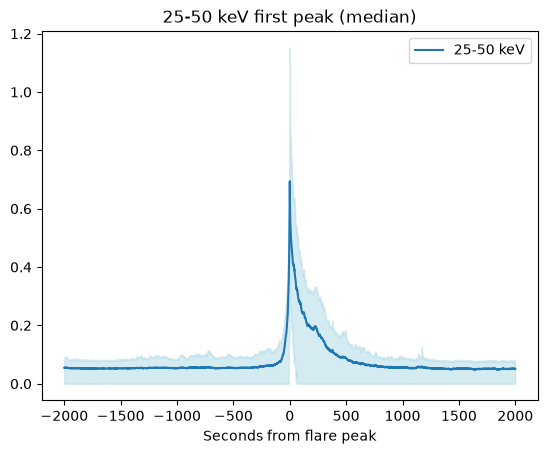

In [373]:
fig, ax = plt.subplots()

ax.plot(median_2550_firstpeak.index, averaged_shape_flare_2550_firstpeak['25.0 keV-50.0 keV'], label = '25-50 keV')
ax.fill_between(median_2550_firstpeak.index, lowerlim_2550_firstpeak, upperlim_2550_firstpeak, color='lightblue', alpha=0.5)
ax.set_xlabel('Seconds from flare peak')
ax.set_title('25-50 keV first peak (median)')
ax.legend()

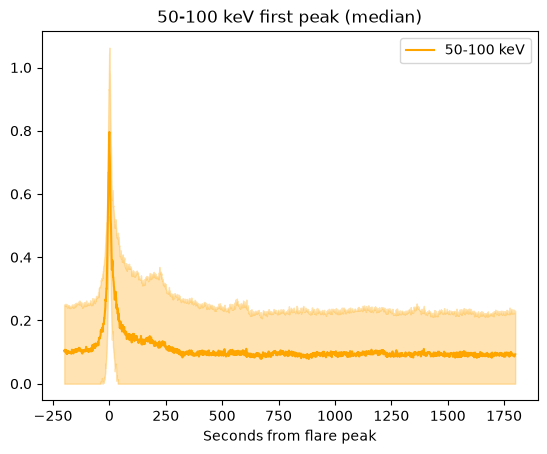

In [37]:
fig, ax = plt.subplots()

ax.plot(median_50100_firstpeak.index, median_50100_firstpeak['50.0 keV-100.0 keV'], label = '50-100 keV', color='orange')
ax.fill_between(median_50100_firstpeak.index, lowerlim_50100_firstpeak, upperlim_50100_firstpeak, color='orange', alpha=0.3)
ax.set_xlabel('Seconds from flare peak')
ax.set_title('50-100 keV first peak (median)')
ax.legend()

In [374]:
df_list_filtered = []
for df in resampled_df_list_peaks:
    df_filtered = df.copy()
    
    filtered_2550 = savgol_filter(df['25.0 keV-50.0 keV'], window_length = 25, polyorder=2)
    filtered_50100 = savgol_filter(df['50.0 keV-100.0 keV'], window_length = 25, polyorder=2)

    df_filtered['25.0 keV-50.0 keV'] = filtered_2550
    df_filtered['50.0 keV-100.0 keV'] = filtered_50100

    df_list_filtered.append(df_filtered)

In [379]:
i=0
peak_counts = []
for df in df_list_filtered:
    if pd.notna(durations[i]):
        df.index = t(df.index)
        bkg = df['25.0 keV-50.0 keV'].loc[starts[i] - dt.timedelta(seconds=30)]
    
        df_flare = df.truncate(starts[i], ends[i])
        
        peaks, properties = find_peaks(df_flare['25.0 keV-50.0 keV'], distance = 10, prominence=3*bkg)
        peak_counts.append(len(peaks))

        df = resampled_df_list[i]
        df_plot = df.truncate(starts[i] - dt.timedelta(minutes=5), ends[i] + dt.timedelta(minutes=5))

        fig, ax = plt.subplots()
        ax.plot(df_plot.index, df_plot['25.0 keV-50.0 keV'])
        ax.scatter(df_flare.index[peaks], df_flare['25.0 keV-50.0 keV'].iloc[peaks], color='black', marker='*', label=str(len(peaks))+' peaks')
        ax.legend()
        fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/peak_testing/flare"+str(i)+".png", bbox_inches='tight')
        
    
    i+=1

plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_38448\3465464580.py:16: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [111]:
peak = np.max(median_2550_firstpeak['25.0 keV-50.0 keV'])
peak_loc = median_2550_firstpeak.index[median_2550_firstpeak['25.0 keV-50.0 keV'] == peak][0]

start_df = median_2550_firstpeak[(median_2550_firstpeak['25.0 keV-50.0 keV'].diff()>0.005) & (median_2550_firstpeak.index<peak_loc)]

found_start=False
for time in start_df.index:
    start = median_2550_firstpeak.index.get_loc(median_2550_firstpeak.index[median_2550_firstpeak.index == time][0])
    points = median_2550_firstpeak['25.0 keV-50.0 keV'].iloc[start:start+3]
    if points.is_monotonic_increasing:
        median_start = time
        found_start=True
        break

if not found_start:
    median_start=np.nan

end_df = median_2550_firstpeak[(median_2550_firstpeak['25.0 keV-50.0 keV']<np.mean(median_2550_firstpeak['25.0 keV-50.0 keV'])) & (median_2550_firstpeak.index>peak_loc)]
if not end_df.empty:
    median_end = end_df.index[0]
else:
    median_end = np.nan

print(median_start, median_end)

-53 279


In [349]:
median_start = -100
median_end = 500

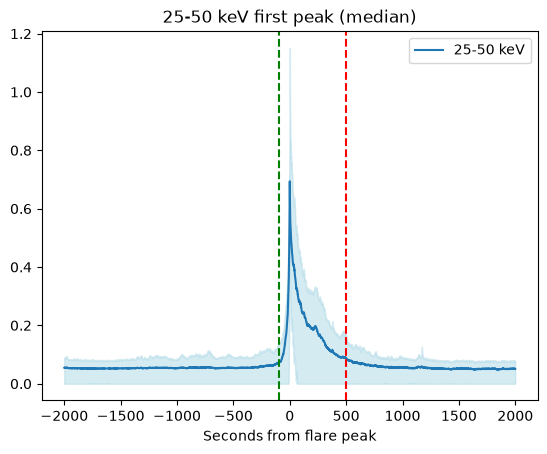

In [375]:
fig, ax = plt.subplots()

ax.plot(median_2550_firstpeak.index, averaged_shape_flare_2550_firstpeak['25.0 keV-50.0 keV'], label = '25-50 keV')
ax.fill_between(median_2550_firstpeak.index, lowerlim_2550_firstpeak, upperlim_2550_firstpeak, color='lightblue', alpha=0.5)
ax.set_xlabel('Seconds from flare peak')
ax.set_title('25-50 keV first peak (median)')
ax.legend()

plt.axvline(median_start, 0, 1, linestyle = 'dashed', color='green')
plt.axvline(median_end, 0, 1, linestyle = 'dashed', color='red')

In [121]:
median_2550_firstpeak

,25.0 keV-50.0 keV
-200,0.036717
-199,0.035997
-198,0.040304
-197,0.037943
-196,0.038788
...,...
1795,0.036181
1796,0.035200
1797,0.036646
1798,0.034965


In [351]:
len(timeshifted_df_list_firstpeak[10])

3000

In [122]:
norm_dur_median_2550 = median_2550_firstpeak.copy()

norm_dur_median_2550.index = norm_dur_median_2550.index - median_start
norm_dur_median_2550 = norm_dur_median_2550.truncate(0, median_end-median_start)
norm_dur_median_2550.index = norm_dur_median_2550.index/(median_end-median_start)

In [125]:
norm_dur_list = []
i=0
for df in normalised_df_list_peaks:
    if pd.notna(durations[i]):
        timeshifted_df = df.copy()
        timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
        
        #
        start = pd.to_datetime(t(starts[i])).round('1s')
        end = pd.to_datetime(t(ends[i])).round('1s')
        #
    
        total_start = (start - dt.datetime(2004, 11, 25)).total_seconds()
        total_end = (end - dt.datetime(2004, 11, 25)).total_seconds()
    
        
        timeshifted_df.index = timeshifted_df.index - total_start
        timeshifted_df = timeshifted_df.truncate(0, total_end-total_start)
        timeshifted_df.index = timeshifted_df.index/(total_end-total_start)
        norm_dur_list.append(timeshifted_df)
    i+=1

In [147]:
resampled_ind = np.linspace(0, 1, 1000)

resampled_corr_list = []
for df in timeshifted_df_list_firstpeak:
    resampled_df = df.reindex(df.index.union(resampled_ind)).interpolate('linear').loc[resampled_ind]
    resampled_corr_list.append(resampled_df)

resampled_median_2550 = median_2550_firstpeak.reindex(median_2550_firstpeak.index.union(resampled_ind)).interpolate('linear').loc[resampled_ind]

In [148]:
from scipy.stats import pearsonr

In [175]:
len(median_2550_firstpeak)

2000

In [150]:
len(norm_dur_median_2550)

601

In [158]:
pearsonr(resampled_corr_list[0]['25.0 keV-50.0 keV'], resampled_median_2550['25.0 keV-50.0 keV'])[0]

np.float64(-1.0)

In [177]:
median_2550_firstpeak['25.0 keV-50.0 keV']

-200     0.036717
-199     0.035997
-198     0.040304
-197     0.037943
-196     0.038788
           ...   
 1795    0.036181
 1796    0.035200
 1797    0.036646
 1798    0.034965
 1799    0.036973
Name: 25.0 keV-50.0 keV, Length: 2000, dtype: float64

In [178]:
df['25.0 keV-50.0 keV']

-200.0    0.273722
-199.0    0.269368
-198.0    0.262113
-197.0    0.259574
-196.0    0.241797
            ...   
 239.0    0.259936
 240.0    0.248535
 241.0    0.259418
 242.0    0.279630
 243.0    0.234024
Name: 25.0 keV-50.0 keV, Length: 444, dtype: float64

In [208]:
durations_f  = []
for dur in durations:
    if pd.notna(dur):
        durations_f.append(dur)

<Axes: >

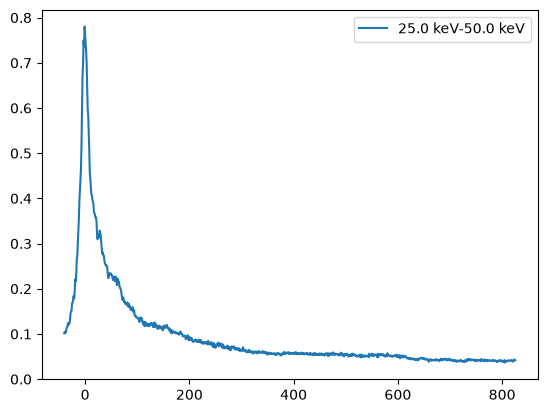

In [257]:
template = median_2550_firstpeak.truncate(total_start-total_peak_time, total_end-total_peak_time)
#template.index = template.index/(median_end-median_start)

new_index = pd.Index(np.arange(total_start-total_peak_time, total_end-total_peak_time, 1)) 
template = template.set_index(template.index).reindex(new_index)

template.plot()

<Axes: >

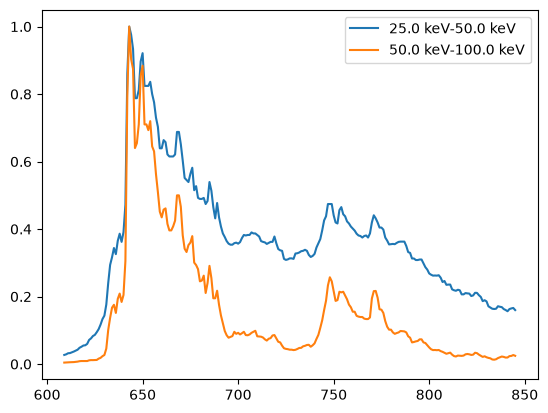

In [352]:
i=0
df = normalised_df_list_peaks[0]
timeshifted_df = df.copy()
timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()

start = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime - dt.timedelta(minutes=10)
end = parse_time(flarelist_refined['end_UTC'].iloc[i]).datetime  + dt.timedelta(minutes=10)

df = df.truncate(start, end)
peak_time = df.index[firstpeaks[i]]
peak_time = pd.to_datetime(t(peak_time)).round('1s')

total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
total_start = (starts[i] - dt.datetime(2004, 11, 25)).total_seconds()
total_end = (ends[i] - dt.datetime(2004, 11, 25)).total_seconds()

timeshifted_df = timeshifted_df.truncate(total_start, total_end)
timeshifted_df.index = timeshifted_df.index - total_peak_time

new_index = pd.Index(np.arange(total_start-total_peak_time, total_end-total_peak_time, 1)) 
df = timeshifted_df.set_index(timeshifted_df.index).reindex(new_index)


#timeshifted_df.index = timeshifted_df.index/(total_end-total_start)

# new_index = pd.Index(np.arange(0, 1, 0.01)) 
# final_df = timeshifted_df.set_index(timeshifted_df.index).reindex(new_index)
#final_df.dropna().shape[0]
df.plot()

In [296]:
len(starts)

164

In [298]:
i=0
firstpeaks_x = []
for peakval in firstpeaks:
    if pd.notna(durations[i]):
        firstpeaks_x.append(peakval)

In [ ]:
 if pd.notna(durations[i]):
        timeshifted_df = df.copy()
        timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()

        bkg = df['25.0 keV-50.0 keV'].loc[starts[i] - dt.timedelta(seconds=30)]
        
        df = df.truncate(starts[i], ends[i])
        peaks, properties = find_peaks(df['25.0 keV-50.0 keV'], prominence=2*bkg)
        
        peak_time = df.index[peaks[0]]
        peak_time = pd.to_datetime(t(peak_time)).round('1s')
    
        total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
        
        timeshifted_df.index = timeshifted_df.index - total_peak_time
        timeshifted_df = timeshifted_df.truncate(-1000, 1999)
        timeshifted_df_list_firstpeak.append(timeshifted_df)
    i+=1

In [376]:
timeshifted_df_list_corr = []
pearsonr_corr =  []
i=0
for df in normalised_df_list_peaks:
    if pd.notna(durations[i]):
        timeshifted_df = df.copy()
        timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
        bkg = df['25.0 keV-50.0 keV'].loc[starts[i] - dt.timedelta(seconds=30)]
        
        df = df.truncate(starts[i], ends[i])
        peaks, properties = find_peaks(df['25.0 keV-50.0 keV'], prominence=2*bkg)
        
        peak_time = df.index[peaks[0]]
        peak_time = pd.to_datetime(t(peak_time)).round('1s')
        
        total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
        total_start = (starts[i] - dt.datetime(2004, 11, 25)).total_seconds()
        total_end = (ends[i] - dt.datetime(2004, 11, 25)).total_seconds()

        timeshifted_df_x = timeshifted_df.truncate(total_start, total_end)
        timeshifted_df_x.index = timeshifted_df_x.index - total_peak_time


        template = median_2550_firstpeak.truncate(total_start-total_peak_time, total_end-total_peak_time)
        
        new_index = pd.Index(np.arange(total_start-total_peak_time, total_end-total_peak_time, 1)) 
        df = timeshifted_df_x.set_index(timeshifted_df_x.index).reindex(new_index)
        timeshifted_df_list_corr.append(df)
        template = template.set_index(template.index).reindex(new_index)

        pr = pearsonr(df['25.0 keV-50.0 keV'], template['25.0 keV-50.0 keV'])[0]
        pearsonr_corr.append(pr)

        timeshifted_df = timeshifted_df.truncate(total_start-60, total_end+60)
        timeshifted_df.index = timeshifted_df.index - total_peak_time

        template = median_2550_firstpeak.truncate(total_start-total_peak_time-60, total_end-total_peak_time+60)
        
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        flare_time = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime
        ax.set_title('Pearson r correlation = '+str(np.round(pr,2)))
        plt.suptitle(flare_time.strftime("%Y-%m-%d %H:%M"))
        
        ax.plot(template.index, template['25.0 keV-50.0 keV'], label='First peak normalised SEA')
        ax.plot(timeshifted_df.index, timeshifted_df['25.0 keV-50.0 keV'], label='25-50 keV')

        plt.axvline(total_start-total_peak_time, 0, 1, linestyle='dashed', color='lightcoral')
        plt.axvline(total_end-total_peak_time, 0, 1, linestyle='dashed', color='lightcoral')
        
        ax.set_xlabel('Seconds from flare start')
        ax.set_ylabel('Normalised counts')
        
        ax.legend()
        fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/pearsonr/flare"+str(i)+".png", bbox_inches='tight')
    i+=1

plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_38448\77319070.py:40: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [215]:
# pearsonr_corr =  []
# i=0
# for df in df_list_pearsonr_fin:
#     template = median_2550_firstpeak#.truncate(-200, -200+durations_f[i])
#     new_index = pd.Index(np.arange(-200, -200+durations_f[i], 1)) 
#     template = template.set_index(template.index).reindex(new_index)
#     pearsonr_corr.append(pearsonr(df['25.0 keV-50.0 keV'], template['25.0 keV-50.0 keV'])[0])
    
#     fig, ax = plt.subplots()
#     ax.set_ylabel('ct/(keV s)')
#     flare_time = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime
#     ax.set_title('Pearson r correlation = '+str(pearsonr_corr[i]))
#     plt.suptitle(flare_time.strftime("%Y-%m-%d %H:%M"))
    
#     ax.plot(template.index, template['25.0 keV-50.0 keV'], label='First peak normalised SEA')
#     ax.plot(df.index, df['25.0 keV-50.0 keV'], label='25-50 keV')
    
#     ax.set_xlabel('Seconds from flare start')
#     ax.set_ylabel('Normalised counts')
    
#     ax.legend()
#     fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/pearsonr/flare"+str(i)+".png", bbox_inches='tight')
#     i+=1

# plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_38448\227855529.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [377]:
np.where(np.array(pearsonr_corr)==np.nan)

(array([], dtype=int64),)

In [378]:
pearsonr_corr

[np.float64(0.5635653153073763),
 np.float64(0.9408144746558069),
 np.float64(0.9408144746558069),
 np.float64(-0.4084133058780931),
 np.float64(-0.4917753238221069),
 np.float64(-0.4917753238221069),
 np.float64(0.42075367484842874),
 np.float64(0.42075367484842874),
 np.float64(0.2858676940277092),
 np.float64(-0.08564398031084522),
 np.float64(-0.4768514446840484),
 np.float64(-0.22610126567654032),
 np.float64(0.8026992808290927),
 np.float64(-0.19062571914632154),
 np.float64(-0.2581441911767884),
 np.float64(0.17948795892765407),
 np.float64(0.17948795892765407),
 np.float64(-0.4255718365234162),
 np.float64(-0.3218612102748526),
 np.float64(-0.10751978638938217),
 np.float64(-0.3400678399998904),
 np.float64(0.6419150791706332),
 np.float64(-0.34594247593356364),
 np.float64(0.5535666381364277),
 np.float64(0.603561185071325),
 np.float64(0.8479784959897498),
 np.float64(-0.4123791022366885),
 np.float64(-0.3539388144622563),
 np.float64(0.8574092926342107),
 np.float64(0.756714

In [285]:
i=0
for df in timeshifted_df_list_firstpeak:
    fig, ax = plt.subplots()
    ax.set_ylabel('ct/(keV s)')
    flare_time = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime
    ax.set_title('Pearson r correlation = '+str(np.round(pearsonr_corr[i], 2))
    plt.suptitle(flare_time.strftime("%Y-%m-%d %H:%M"))
    
    ax.plot(median_2550_firstpeak.index,median_2550_firstpeak['25.0 keV-50.0 keV'], label='First peak normalised SEA')
    ax.plot(df.index, df['25.0 keV-50.0 keV'], label='25-50 keV')
    
    ax.set_xlabel('Seconds from flare start')
    ax.set_ylabel('Normalised counts')
    
    #ax.fill_between(median_2550_firstpeak.index, lowerlim_2550_firstpeak, upperlim_2550_firstpeak, color='lightblue', alpha=0.5)
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize='small')
    fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/pearsonr/flare"+str(i)+".png", bbox_inches='tight')
    i+=1

plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_38448\3410645976.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()
